Explainable Transformer Based Framework for Early Detection of Mental Health Disorders from Social Media Text

---

### imports and paths

In [1]:
import pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)

SPLITS      = Path('..') / 'datasets' / 'processed' / 'splits'
MODELS_DIR  = Path('..') / 'models' / 'saved'
RESULTS_DIR = Path('..') / 'results'
CHARTS_DIR  = RESULTS_DIR / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# CPU is faster than MPS for small models due to lower transfer overhead
DEVICE = torch.device('cpu')

SAVE_THRESHOLD = 0.75
RANDOM_SEED    = 42
torch.manual_seed(RANDOM_SEED)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})
print('device:', DEVICE)

device: cpu


---

### load splits and build vocabulary

In [2]:
train = pd.read_csv(SPLITS / 'train.csv')
val   = pd.read_csv(SPLITS / 'val.csv')
test  = pd.read_csv(SPLITS / 'test.csv')

with open(SPLITS / 'label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)

# build word → index vocabulary from training set only
PAD, UNK = '<PAD>', '<UNK>'
counter = Counter()
for text in train['clean_text'].fillna('').astype(str):
    counter.update(text.split())

# keep words that appear at least 2 times
vocab = {PAD: 0, UNK: 1}
for word, freq in counter.items():
    if freq >= 2:
        vocab[word] = len(vocab)

# save vocabulary for inference
with open(MODELS_DIR / 'dl_vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

print(f'vocabulary size : {len(vocab):,}')
print(f'classes         : {CLASS_NAMES}')
print(f'train / val / test: {len(train):,} / {len(val):,} / {len(test):,}')

vocabulary size : 22,008
classes         : ['Anxiety/Stress', 'Bipolar', 'Depression', 'Normal', 'Suicidal']
train / val / test: 33,159 / 7,106 / 7,106


### dataset and dataloader

In [3]:
MAX_LEN    = 64    # shorter sequences = faster per-batch computation
BATCH_SIZE = 128   # larger batches = fewer iterations per epoch

def encode(text, vocab, max_len):
    tokens = text.split()[:max_len]
    ids    = [vocab.get(t, vocab[UNK]) for t in tokens]
    ids   += [vocab[PAD]] * (max_len - len(ids))
    return ids


class TextDataset(Dataset):
    def __init__(self, df, vocab, max_len):
        self.X = [
            encode(str(t), vocab, max_len)
            for t in df['clean_text'].fillna('').astype(str)
        ]
        self.y = df['label_encoded'].values.tolist()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (torch.tensor(self.X[idx], dtype=torch.long),
                torch.tensor(self.y[idx], dtype=torch.long))


train_ds = TextDataset(train, vocab, MAX_LEN)
val_ds   = TextDataset(val,   vocab, MAX_LEN)
test_ds  = TextDataset(test,  vocab, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, num_workers=0)

print(f'batches — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}')

batches — train: 260  val: 56  test: 56


### class weights for imbalanced data

In [4]:
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight('balanced',
                          classes=np.arange(NUM_CLASSES),
                          y=train['label_encoded'].values)
class_weights = torch.tensor(cw, dtype=torch.float).to(DEVICE)
print('class weights:', np.round(cw, 3))

class weights: [1.627 3.79  0.631 0.706 0.893]


### training helper

In [5]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    best_val_f1, best_state = 0.0, None
    history = {'train_loss': [], 'val_f1': []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            out  = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        all_preds = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                preds = model(X_batch.to(DEVICE)).argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
        val_f1 = f1_score(val['label_encoded'].values, all_preds, average='macro')

        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        history['val_f1'].append(val_f1)
        print(f'  epoch {epoch:2d}  loss {avg_loss:.4f}  val-F1 {val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        scheduler.step()

    model.load_state_dict(best_state)
    return model, history


def evaluate_model(name, model, loader, y_true):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for X_batch, _ in loader:
            preds = model(X_batch.to(DEVICE)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
    acc = accuracy_score(y_true, all_preds)
    f1  = f1_score(y_true, all_preds, average='macro')
    print(f'\n{name} — test set')
    print(f'  accuracy : {acc:.4f}')
    print(f'  macro-F1 : {f1:.4f}')
    print(classification_report(y_true, all_preds, target_names=CLASS_NAMES, digits=3))
    return acc, f1, all_preds


def plot_confusion(name, preds, y_true):
    cm     = confusion_matrix(y_true, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{name} — confusion matrix (normalised, test set)')
    ax.set_xlabel('predicted')
    ax.set_ylabel('actual')
    plt.xticks(rotation=30, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    fname = name.lower().replace(' ', '_')
    fig.savefig(CHARTS_DIR / f'confusion_{fname}.png', bbox_inches='tight')
    plt.show()
    print(f'saved: charts/confusion_{fname}.png')


def plot_history(name, history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
    ax1.plot(history['train_loss'], marker='o')
    ax1.set_title(f'{name} — training loss')
    ax1.set_xlabel('epoch')
    ax2.plot(history['val_f1'], marker='o', color='tomato')
    ax2.set_title(f'{name} — validation macro-F1')
    ax2.set_xlabel('epoch')
    plt.tight_layout()
    fname = name.lower().replace(' ', '_')
    fig.savefig(CHARTS_DIR / f'training_curve_{fname}.png', bbox_inches='tight')
    plt.show()
    print(f'saved: charts/training_curve_{fname}.png')

print('helpers defined')

helpers defined


---

### CNN

In [6]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes,
                 num_filters=128, kernel_sizes=(2, 3, 4), dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # parallel convolutions with different window sizes capture n-gram features
        self.convs = nn.ModuleList([
            nn.Conv2d(1, num_filters, (k, embed_dim)) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(x)).squeeze(3)
            c = torch.max(c, dim=2).values
            pooled.append(c)
        out = torch.cat(pooled, dim=1)
        out = self.dropout(out)
        return self.fc(out)


cnn_model = TextCNN(
    vocab_size=len(vocab),
    embed_dim=64,
    num_classes=NUM_CLASSES,
).to(DEVICE)

print('CNN params:', sum(p.numel() for p in cnn_model.parameters() if p.requires_grad))
print('training CNN ...')
cnn_model, cnn_history = train_model(cnn_model, train_loader, val_loader, epochs=5)

CNN params: 1484549
training CNN ...


  epoch  1  loss 1.2329  val-F1 0.6415


  epoch  2  loss 0.8448  val-F1 0.6640


  epoch  3  loss 0.7342  val-F1 0.7024


  epoch  4  loss 0.6534  val-F1 0.7044


  epoch  5  loss 0.6187  val-F1 0.7115


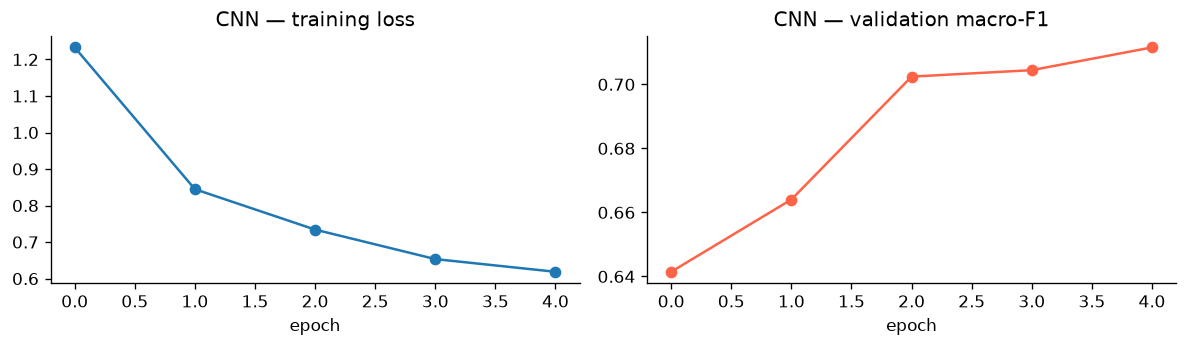

saved: charts/training_curve_cnn.png



CNN — test set
  accuracy : 0.7329
  macro-F1 : 0.7270
                precision    recall  f1-score   support

Anxiety/Stress      0.731     0.801     0.765       874
       Bipolar      0.620     0.819     0.706       375
    Depression      0.685     0.677     0.681      2252
        Normal      0.876     0.874     0.875      2014
      Suicidal      0.645     0.575     0.608      1591

      accuracy                          0.733      7106
     macro avg      0.712     0.749     0.727      7106
  weighted avg      0.733     0.733     0.731      7106



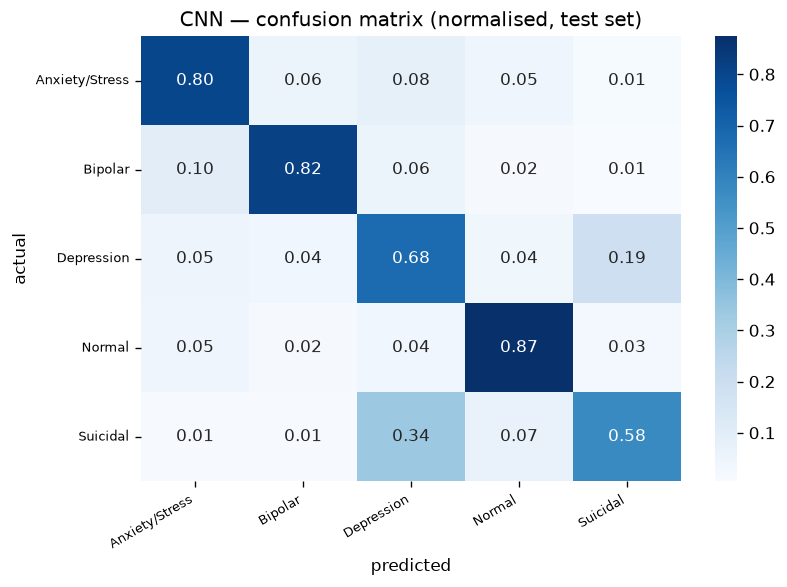

saved: charts/confusion_cnn.png


In [7]:
plot_history('CNN', cnn_history)
cnn_acc, cnn_f1, cnn_preds = evaluate_model('CNN', cnn_model, test_loader,
                                             test['label_encoded'].values)
plot_confusion('CNN', cnn_preds, test['label_encoded'].values)

In [8]:
if cnn_f1 >= SAVE_THRESHOLD:
    torch.save(cnn_model.state_dict(), MODELS_DIR / 'cnn.pt')
    print(f'CNN saved  (macro-F1 {cnn_f1:.4f} >= {SAVE_THRESHOLD})')
else:
    print(f'CNN NOT saved  (macro-F1 {cnn_f1:.4f} below {SAVE_THRESHOLD})')

CNN NOT saved  (macro-F1 0.7270 below 0.75)


---

### BiLSTM

In [9]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # bidirectional LSTM reads sequence both forward and backward
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        # hidden_dim * 2 because forward + backward directions are concatenated
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x   = self.embedding(x)
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


bilstm_model = BiLSTM(
    vocab_size=len(vocab),
    embed_dim=64,
    hidden_dim=128,
    num_classes=NUM_CLASSES,
).to(DEVICE)

print('BiLSTM params:', sum(p.numel() for p in bilstm_model.parameters() if p.requires_grad))
print('training BiLSTM ...')
bilstm_model, bilstm_history = train_model(bilstm_model, train_loader, val_loader, epochs=5)

BiLSTM params: 2003717
training BiLSTM ...


  epoch  1  loss 1.3253  val-F1 0.3808


  epoch  2  loss 1.1476  val-F1 0.5208


  epoch  3  loss 0.9753  val-F1 0.5530


  epoch  4  loss 0.8293  val-F1 0.6083


  epoch  5  loss 0.7602  val-F1 0.6276


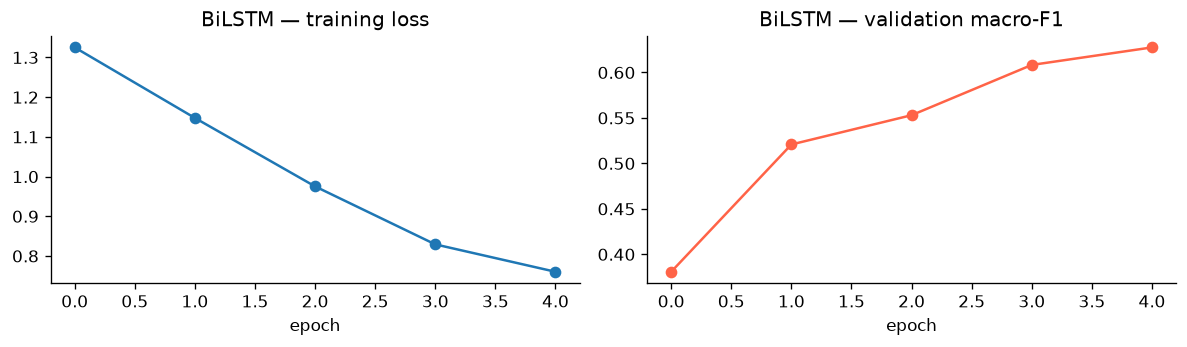

saved: charts/training_curve_bilstm.png



BiLSTM — test set
  accuracy : 0.6409
  macro-F1 : 0.6288
                precision    recall  f1-score   support

Anxiety/Stress      0.584     0.683     0.630       874
       Bipolar      0.456     0.795     0.579       375
    Depression      0.634     0.421     0.506      2252
        Normal      0.898     0.833     0.864      2014
      Suicidal      0.500     0.650     0.565      1591

      accuracy                          0.641      7106
     macro avg      0.614     0.676     0.629      7106
  weighted avg      0.663     0.641     0.640      7106



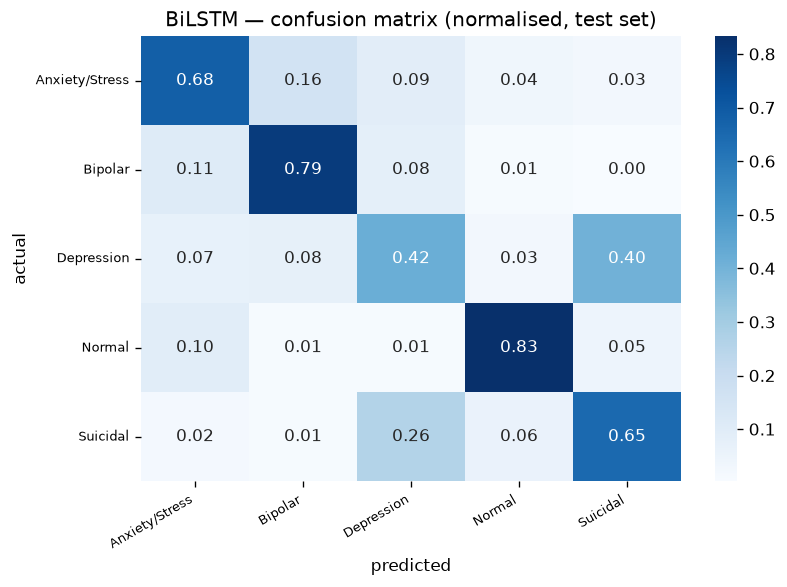

saved: charts/confusion_bilstm.png


In [10]:
plot_history('BiLSTM', bilstm_history)
bilstm_acc, bilstm_f1, bilstm_preds = evaluate_model('BiLSTM', bilstm_model, test_loader,
                                                       test['label_encoded'].values)
plot_confusion('BiLSTM', bilstm_preds, test['label_encoded'].values)

In [11]:
if bilstm_f1 >= SAVE_THRESHOLD:
    torch.save(bilstm_model.state_dict(), MODELS_DIR / 'bilstm.pt')
    print(f'BiLSTM saved  (macro-F1 {bilstm_f1:.4f} >= {SAVE_THRESHOLD})')
else:
    print(f'BiLSTM NOT saved  (macro-F1 {bilstm_f1:.4f} below {SAVE_THRESHOLD})')

BiLSTM NOT saved  (macro-F1 0.6288 below 0.75)


---

### comparison


DL model comparison (test set):
        accuracy  macro_f1
CNN       0.7329    0.7270
BiLSTM    0.6409    0.6288


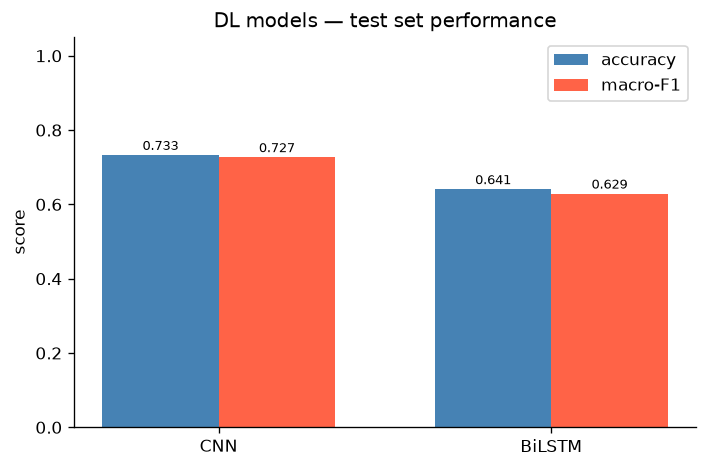

results saved to dl_results.json


In [12]:
results = {
    'CNN':    {'accuracy': cnn_acc,    'macro_f1': cnn_f1},
    'BiLSTM': {'accuracy': bilstm_acc, 'macro_f1': bilstm_f1},
}

res_df = pd.DataFrame(results).T.round(4)
print('\nDL model comparison (test set):')
print(res_df.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(results))
w = 0.35
ax.bar(x - w/2, [v['accuracy'] for v in results.values()], w, label='accuracy', color='steelblue')
ax.bar(x + w/2, [v['macro_f1'] for v in results.values()], w, label='macro-F1', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(list(results.keys()))
ax.set_ylim(0, 1.05)
ax.set_ylabel('score')
ax.set_title('DL models — test set performance')
ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# save for final comparison notebook
with open(MODELS_DIR / 'dl_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('results saved to dl_results.json')